In [27]:
# Importing the Libraries
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from os import getcwd
import matplotlib.pyplot as plt

In [3]:
# Loading the Data
data_train = pd.read_csv('sign_mnist_train.csv')
data_test = pd.read_csv('sign_mnist_test.csv')

In [5]:
# Now let's prepare the data then I will split the data into training and test sets
training_images = data_train.iloc[:,1:].values
training_labels = data_train.iloc[:,0].values

In [7]:
testing_images = data_test.iloc[:,1:].values
testing_labels = data_test.iloc[:,0].values

In [9]:
training_images = training_images.reshape(-1,28,28,1)

In [11]:
testing_images = testing_images.reshape(-1,28,28,1)

In [13]:
training_images.shape

(27455, 28, 28, 1)

In [15]:
training_labels.shape

(27455,)

In [17]:
testing_images.shape

(7172, 28, 28, 1)

In [19]:
testing_labels.shape

(7172,)

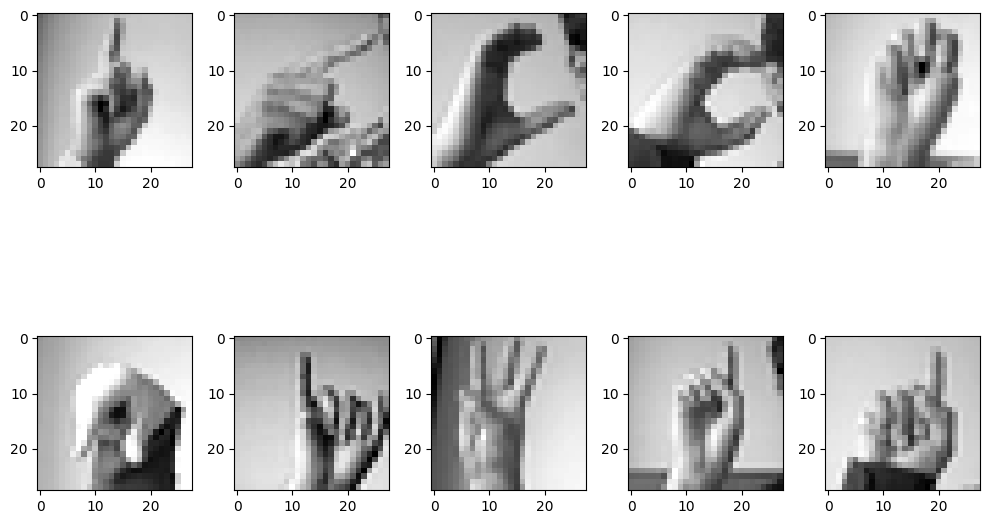

In [29]:
# Now let’s have a look at the first 10 images in the dataset
fig, ax = plt.subplots(2,5)
fig.set_size_inches(10,10)
k = 0
for i in range(2):
    for j in range(5):
        ax[i,j].imshow(training_images[k].reshape(28,28), cmap = 'grey')
        k+=1
    plt.tight_layout()

In [31]:
# Now let's create an ImageDataGenerator and do Image Augmentation of the dataset
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(
    rescale=1 / 255
)
    
# Keep These
print(training_images.shape)
print(testing_images.shape)

(27455, 28, 28, 1)
(7172, 28, 28, 1)


#### Training Neural Network


In [38]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Example: If your data is already loaded into these variables
# training_images, training_labels, testing_images, testing_labels

# Reshape and normalize images (important for CNN input and faster convergence)
training_images = training_images.reshape(-1, 28, 28, 1).astype('float32') / 255.0
testing_images = testing_images.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# Image Data Generator for augmentation (optional, but useful for better generalization)
train_datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

validation_datagen = ImageDataGenerator()

# Define the CNN Model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(26, activation='softmax')  # 26 output classes (A-Z)
])

# Compile the Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the Model using model.fit()
history = model.fit(
    train_datagen.flow(training_images, training_labels, batch_size=32),
    steps_per_epoch=len(training_images) // 32,
    epochs=10,
    validation_data=validation_datagen.flow(testing_images, testing_labels, batch_size=32),
    validation_steps=len(testing_images) // 32
)

# Evaluate Model
test_loss, test_accuracy = model.evaluate(testing_images, testing_labels, verbose=0)
print(f"Test accuracy: {test_accuracy:.4f}")


Epoch 1/10


C:\Users\irt\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\irt\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


857/857 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.3777 - loss: 2.0822 - val_accuracy: 0.8920 - val_loss: 0.3688
Epoch 2/10
  1/857 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.7500 - loss: 0.6449

C:\Users\irt\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


857/857 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7500 - loss: 0.6449 - val_accuracy: 0.8877 - val_loss: 0.3690
Epoch 3/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.8405 - loss: 0.4793 - val_accuracy: 0.9678 - val_loss: 0.1225
Epoch 4/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8438 - loss: 0.3030 - val_accuracy: 0.9686 - val_loss: 0.1178
Epoch 5/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9266 - loss: 0.2265 - val_accuracy: 0.9752 - val_loss: 0.0857
Epoch 6/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9062 - loss: 0.2331 - val_accuracy: 0.9704 - val_loss: 0.0900
Epoch 7/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.9540 - loss: 0.1414 - val_accuracy: 0.9805 - val_loss: 0.0588
Epoch 8/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9375 - loss: 0.0759 - val_accuracy: 0.9789 - val_loss: 0.0631
Epoch 9/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9656 - loss: 0.1070 - val_accuracy: 0.976

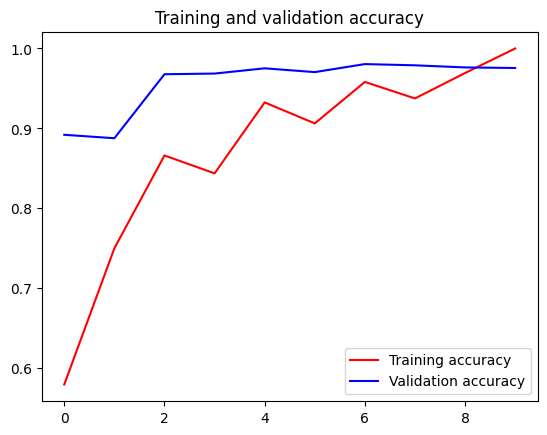

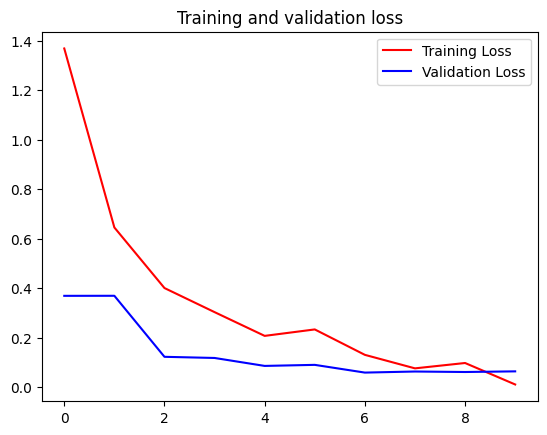

In [40]:
# Now let’s have a look at the accuracy and validation score of the model
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc=0)
plt.figure()

plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()


plt.show()

In [48]:
# Example: Skipping 'I' and 'J' and 'O' if your dataset excludes them
import string

# Define the label values (e.g., integers 0–25 skipping 8, 9, 14 for 'I', 'J', 'O')
label_values = [i for i in range(26) if i not in [8, 9, 14]]

# Define class names accordingly
class_names = [char for i, char in enumerate(string.ascii_uppercase) if i not in [8, 9, 14]]


In [50]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Predict class probabilities and convert to labels
pred_probs = model.predict(testing_images)
pred_classes = np.argmax(pred_probs, axis=1)

# Classification report (fixing the mismatch using `labels` parameter)
print(classification_report(testing_labels, pred_classes,
                            labels=label_values,
                            target_names=class_names))


225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

           A       1.00      0.99      1.00       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       0.92      1.00      0.96       245
           E       0.99      0.98      0.99       498
           F       1.00      1.00      1.00       247
           G       0.99      0.83      0.90       348
           H       1.00      1.00      1.00       436
           K       1.00      0.94      0.97       331
           L       1.00      1.00      1.00       209
           M       1.00      0.96      0.98       394
           N       1.00      0.97      0.99       291
           P       1.00      1.00      1.00       347
           Q       0.98      1.00      0.99       164
           R       0.89      1.00      0.94       144
           S       0.84      1.00      0.91       246
           T       0.80      0.91      

C:\Users\irt\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\irt\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\irt\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\irt\anaconda3\Lib\site-packages\sklear

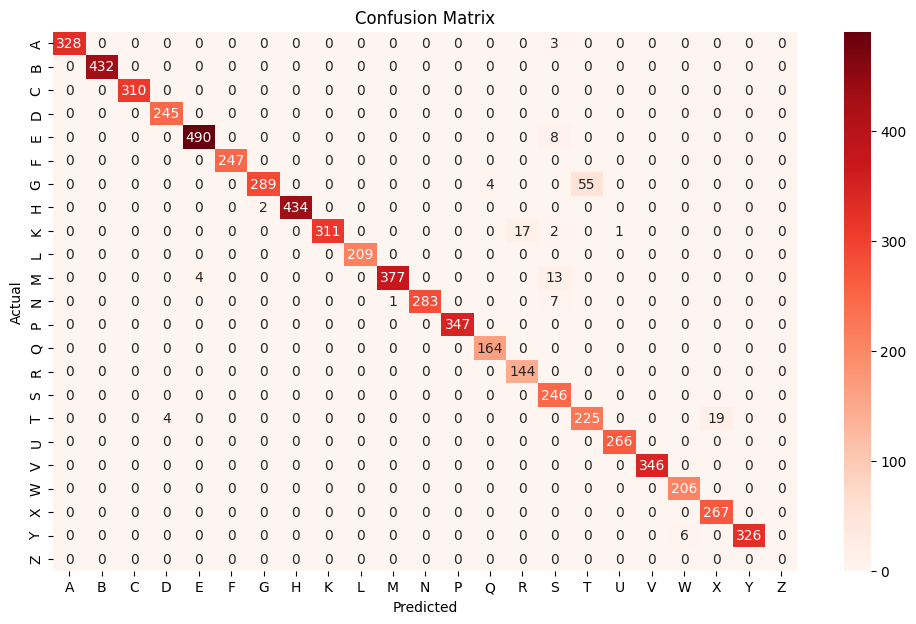

In [52]:
# Confusion matrix
cm = confusion_matrix(testing_labels, pred_classes, labels=label_values)

# Plot it
plt.figure(figsize=(12, 7))
sns.heatmap(cm, annot=True, fmt='g', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
